In [1]:
%matplotlib widget

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import tqdm

from bscarlos.settings import RAW_DATA_FOLDER#, PROCESSED_DATA_FOLDER
from bscarlos.detector import ClusteringDetector

In [2]:
data_attributes = pd.read_csv(RAW_DATA_FOLDER / 'data_attributes.csv').set_index("unique_patient_id")
data_attributes.head(16)

,patient_id,start_sample,end_sample,sample_rate
unique_patient_id,,,,
Pat00,P1,4185435,4918141,200.0
Pat01,P2,12681997,13408848,200.0
Pat02,P3,39835,764218,200.0
Pat03,P4,10844009,11573448,200.0
Pat04,P5,901647,1624579,200.0
Pat05,P6,1498558,2228672,200.0
Pat06,P7,26427086,28254747,500.0
Pat07,P8,5288360,7117935,500.0
Pat08,P9,10352423,12177350,500.0


Check `sample_rate` frequency for patient 11

In [3]:
print(data_attributes['sample_rate'].iloc[16])

200.0


### Load Data Files

In [4]:
data_files = sorted(list(RAW_DATA_FOLDER.glob('*.parquet')))

### Create `patient_data` dictionary
store all relavant information for BSUPP Algorithm

In [5]:
patient15_data = pd.read_parquet(data_files[15])
patient15_data.head()

,0,1,2,3,4,5,ground_truth
0,3.714146e-17,-6.487544e-16,-5.876955e-16,-3.476809e-16,8.327476e-17,1.480984e-17,0.0
1,1.520982e-15,-2.309116e-14,-2.081187e-14,-1.217943e-14,2.975902e-15,5.642679e-16,0.0
2,3.103057e-14,-4.096985e-13,-3.673538e-13,-2.120755e-13,5.302245e-14,1.067627e-14,0.0
3,4.203461e-13,-4.837200e-12,-4.314611e-12,-2.449904e-12,6.287660e-13,1.339311e-13,0.0
4,4.252294e-12,-4.280542e-11,-3.798039e-11,-2.114488e-11,5.589388e-12,1.254878e-12,0.0


### Create Learning and Testing Data
Seprating data based on:
- Learning period == First 15min Window
- Testing period >= 15min

In [6]:
fs = 200
learning_period_s = 60*15 
data_learning = patient15_data.iloc[0:fs*learning_period_s]
data_learning.index = data_learning.index*pd.Timedelta(1/fs, 's')
data_testing = patient15_data.iloc[fs*learning_period_s:]
data_testing.index = data_testing.index*pd.Timedelta(1/fs, 's')

In [7]:
def plot_eeg(df):
    t_s = (df.index/pd.Timedelta(1, 's')).to_numpy()

    plt.figure()

    for i, col in enumerate(df):

        scale = 1
        if str(col) not in {'0', '1', '2', '3', '4', '5'}:
            scale = 50

        x = df[col].to_numpy()
        plt.plot(t_s, scale*x+100*i, label=col)

    plt.xlabel('time [s]')

    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=4)
    plt.tight_layout()

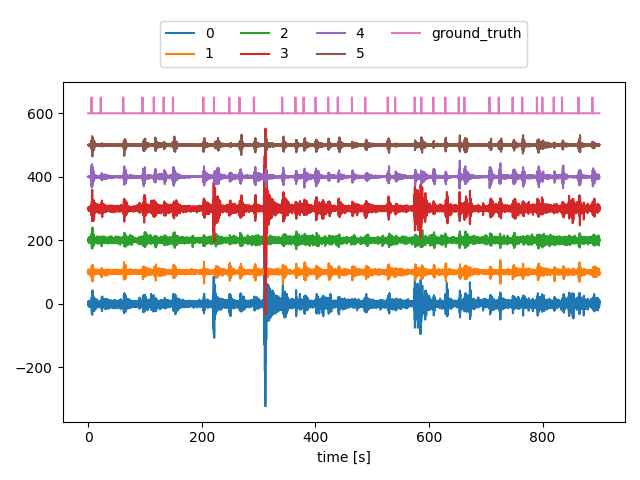

In [8]:
plot_eeg(data_learning)

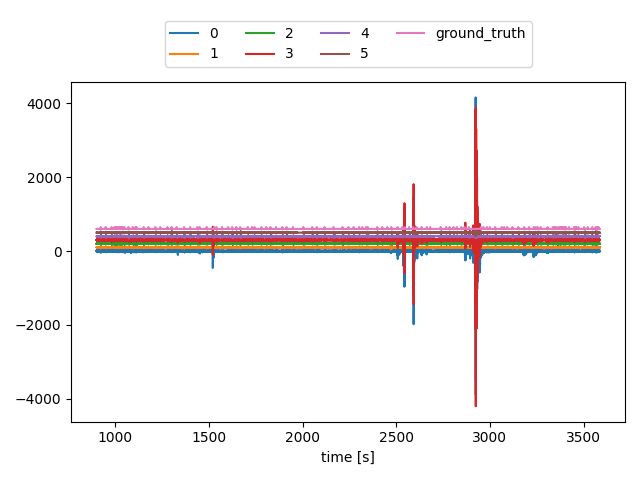

In [9]:
plot_eeg(data_testing)

### Create EEG-only Data 
Dropping 'ground_truth' column from learning and testing datasets


In [10]:
eeg_cols = [str(i) for i in range(6)]

In [11]:
# separate eeg
eeg_learning = data_learning[eeg_cols]
eeg_learning.head()

,0,1,2,3,4,5
0 days 00:00:00,3.714146e-17,-6.487544e-16,-5.876955e-16,-3.476809e-16,8.327476e-17,1.480984e-17
0 days 00:00:00.005000,1.520982e-15,-2.309116e-14,-2.081187e-14,-1.217943e-14,2.975902e-15,5.642679e-16
0 days 00:00:00.010000,3.103057e-14,-4.096985e-13,-3.673538e-13,-2.120755e-13,5.302245e-14,1.067627e-14
0 days 00:00:00.015000,4.203461e-13,-4.837200e-12,-4.314611e-12,-2.449904e-12,6.287660e-13,1.339311e-13
0 days 00:00:00.020000,4.252294e-12,-4.280542e-11,-3.798039e-11,-2.114488e-11,5.589388e-12,1.254878e-12


### Apply Clustering Detector on patient 15

In [12]:
detector = ClusteringDetector()
detector.fit(eeg_learning)

c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


In [13]:
def combine_windows_with_labels(windows, labels):
    label_datasets = []
    for label, window in zip(labels, windows):
        temp = pd.DataFrame(index=window.index, data={})
        temp['label'] = label
        label_datasets.append(temp)
    return pd.concat(label_datasets)

In [14]:
labels_frame = combine_windows_with_labels(detector.get_windows(eeg_learning), detector.labels_)
data_learning_labeled = data_learning.copy()
data_learning_labeled['label'] = labels_frame['label']

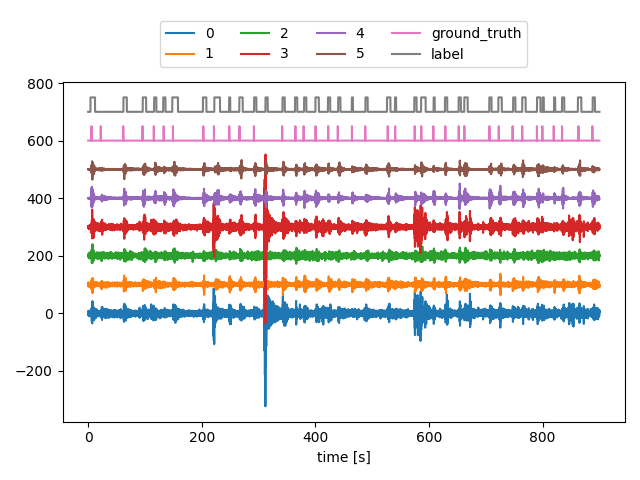

In [15]:
plot_eeg(data_learning_labeled)

####  Make predictions 

In [16]:
data_testing_cropped = data_testing.iloc[0:60*15*fs, :]

In [17]:
eeg_testing = data_testing_cropped[eeg_cols]
eeg_testing.head()

,0,1,2,3,4,5
0 days 00:15:00,9.725041,-6.001034,-3.340294,-1.513002,-1.218047,-0.744005
0 days 00:15:00.005000,9.495252,-6.198037,-3.067064,-2.213263,-1.164321,-0.762894
0 days 00:15:00.010000,9.356311,-6.339695,-2.730090,-2.885864,-1.081898,-0.770050
0 days 00:15:00.015000,9.308528,-6.403308,-2.328351,-3.482504,-0.974298,-0.772010
0 days 00:15:00.020000,9.328757,-6.385387,-1.869810,-3.982637,-0.849825,-0.779591


In [18]:
print(eeg_testing.shape)

(180000, 6)


In [19]:
labels_predicted = detector.predict(eeg_testing)

In [20]:
print(len(labels_predicted))

450


In [21]:
labels_frame_training = combine_windows_with_labels(detector.get_windows(eeg_testing), labels_predicted)
data_testing_cropped_labeled = data_testing_cropped.copy()
data_testing_cropped_labeled['label'] = labels_frame_training['label']

In [22]:
data_testing_cropped_labeled.head()

,0,1,2,3,4,5,ground_truth,label
0 days 00:15:00,9.725041,-6.001034,-3.340294,-1.513002,-1.218047,-0.744005,0.0,0
0 days 00:15:00.005000,9.495252,-6.198037,-3.067064,-2.213263,-1.164321,-0.762894,0.0,0
0 days 00:15:00.010000,9.356311,-6.339695,-2.730090,-2.885864,-1.081898,-0.770050,0.0,0
0 days 00:15:00.015000,9.308528,-6.403308,-2.328351,-3.482504,-0.974298,-0.772010,0.0,0
0 days 00:15:00.020000,9.328757,-6.385387,-1.869810,-3.982637,-0.849825,-0.779591,0.0,0


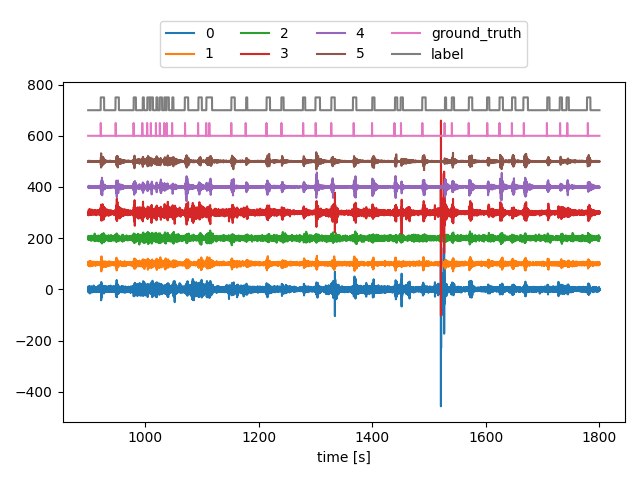

In [23]:
plot_eeg(data_testing_cropped_labeled)

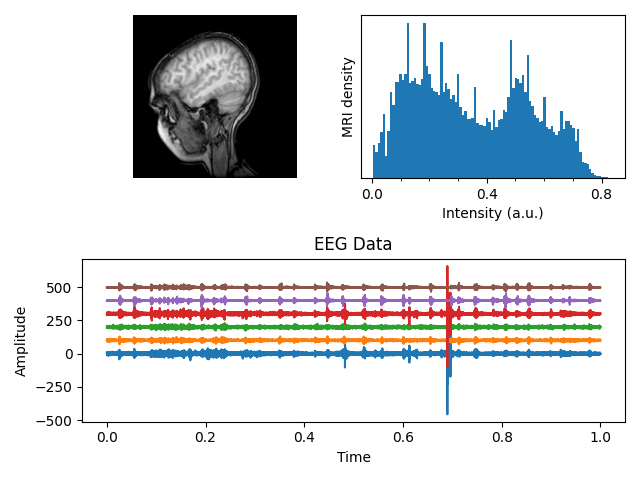

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cbook as cbook
import matplotlib.cm as cm

from matplotlib.collections import LineCollection
from matplotlib.ticker import MultipleLocator

fig = plt.figure("MRI_with_EEG")

# Load the MRI data (256x256 16 bit integers)
with cbook.get_sample_data('s1045.ima.gz') as dfile:
    im = np.frombuffer(dfile.read(), np.uint16).reshape((256, 256))

# Plot the MRI image
ax0 = fig.add_subplot(2, 2, 1)
ax0.imshow(im, cmap=cm.gray)
ax0.axis('off')

# Plot the histogram of MRI intensity
ax1 = fig.add_subplot(2, 2, 2)
im = np.ravel(im)
im = im[np.nonzero(im)]  # Ignore the background
im = im / (2**16 - 1)  # Normalize
ax1.hist(im, bins=100)
ax1.xaxis.set_major_locator(MultipleLocator(0.4))
ax1.minorticks_on()
ax1.set_yticks([])
ax1.set_xlabel('Intensity (a.u.)')
ax1.set_ylabel('MRI density')

# Load the EEG data
n_samples = 180000  # Number of samples from your example data
data = eeg_testing.copy()
data = np.array([float(x) for x in data.iloc[0].values])

# Plot the EEG data
t_s = np.arange(n_samples) / n_samples  # Assuming equal intervals between measurements

ax2 = fig.add_subplot(2, 1, 2)
ax2.set_title('EEG Data')
ax2.set_xlabel('Time')
ax2.set_ylabel('Amplitude')
for i, col in enumerate(eeg_testing.columns):
    x = eeg_testing[col].to_numpy()
    plt.plot(t_s, x+100*i, label=col)

# Adjust layout
fig.tight_layout()

plt.show()

In [25]:
data_testing_cropped_labeled['ground_truth'].shape


(180000,)

In [26]:
data_testing_cropped_labeled['label'].shape


(180000,)

#### Calculate Specificity and Sensitivity

In [27]:
from sklearn.metrics import confusion_matrix

# calculate specificity and sensitivity for patient 15
true_labels = data_testing_cropped_labeled['ground_truth']  # ground truth labels
scores = data_testing_cropped_labeled['label']  # predicted labels

confusion_matrix = confusion_matrix(true_labels, scores)
specificity = confusion_matrix[0, 0] / (confusion_matrix[0, 0] + confusion_matrix[0, 1])
sensitivity = confusion_matrix[1, 1] / (confusion_matrix[1, 0] + confusion_matrix[1, 1])
print(f"Specificity: {specificity:.2f}")
print(f"Sensitivity: {sensitivity:.2f}")


Specificity: 0.80
Sensitivity: 0.53


#### Calculate Burst Per Minute (BPM)


##### Calculate Mean Absolute Error (MAE) of BPM

### Calculate AUROC 

In [28]:
# calculate auroc for patient 15
from sklearn.metrics import auc, roc_curve

fpr, tpr, _ = roc_curve(true_labels, scores)
auroc = auc(fpr, tpr)
print(f"AUROC: {auroc:.2f}")
                                                               

AUROC: 0.67


#### Plot ROC and AUROC Curves

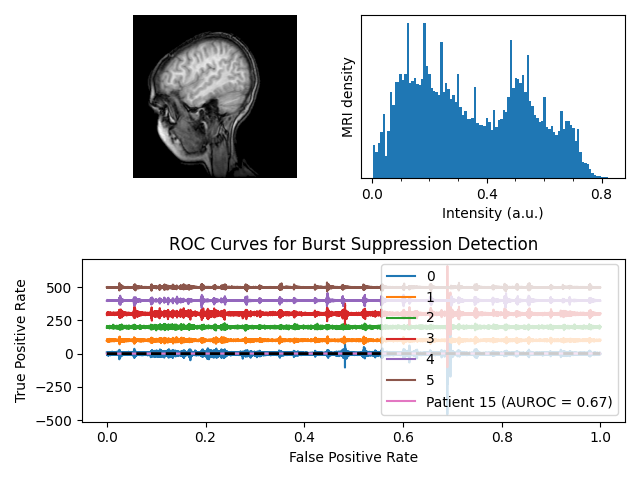

In [29]:
# plot roc and auroc curves for patient 15

plt.plot(fpr, tpr, label=f'Patient 15 (AUROC = {auroc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal dashed line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Burst Suppression Detection')
plt.legend(loc="lower right")
plt.show()

In [30]:
# data_testing

to do: 
- save calculated predictions as parquet file
- plot results for a couple of patients from patient_data dictionary
- widen ground truth by 2s
- compare results in all patients:
    - check in which direction to fill bfill() method
    -   extend ground truth by fill forward ffill() method
    -   visually inspect to see which direction
- calculate the difference between (.labels_ - ground_truth)=False positves and (ground_truth - labels_)=False negatives
- research literature to see validation methods; send to Jenny
- run rf on all patients
- compare clusteringdector to rf